# **Import Library**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)


---
# **Memuat Dataset**

In [22]:
file = '/content/netflix_titles(Bersih).csv'
df = pd.read_csv(file)

# Konversi date_added ke datetime & ekstrak fitur tambahan
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Ekstrak negara utama dari kolom country
df['primary_country'] = df['country'].fillna('Unknown').str.split(',').str[0].str.strip()

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,United States
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,Unknown
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,Unknown
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,India


---
# **Exploratory Data Analysis (EDA)**

**Exploratory Data Analysis (EDA)** adalah tahap analisis awal yang bertujuan untuk menemukan pola, anomali, dan hubungan dalam data menggunakan statistik ringkas dan visualisasi.

EDA dilakukan dengan 4 pendekatan:
1. **Comparison** — Membandingkan kategori
2. **Composition** — Melihat komposisi/proporsi
3. **Distribution** — Melihat sebaran data
4. **Relationship** — Mencari hubungan antar variabel


---
## **1.1 Comparison — Movie vs TV Show**

**Aktivitas:** Membandingkan jumlah konten berdasarkan tipe (Movie vs TV Show).

**Tujuan:** Mengidentifikasi tipe konten mana yang paling dominan di Netflix.

**Visualisasi:** Bar Chart


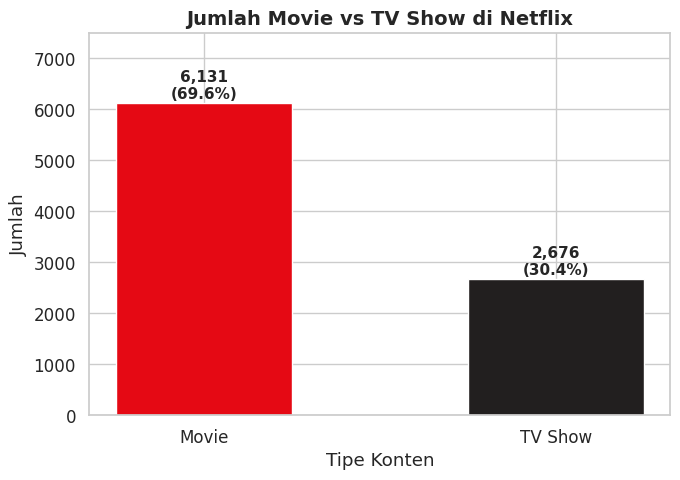

In [23]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(type_counts.index, type_counts.values,
               color=['#E50914', '#221F1F'], width=0.5, edgecolor='white')
plt.title('Jumlah Movie vs TV Show di Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Konten')
plt.ylabel('Jumlah')
plt.ylim(0, 7500)
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

**Insight**
- **Movie** jauh mendominasi dengan **6.131 judul (69.6%)** dibanding TV Show yang hanya **2.676 judul (30.4%)**.
- Rasio hampir **7:3** — artinya dari setiap 10 konten Netflix, 7 di antaranya adalah film.

**Rekomendasi Tindakan**
- Bagi **kreator konten**, memproduksi film memiliki peluang lebih besar untuk masuk katalog Netflix.
- Bagi **pengguna** yang suka series panjang, Netflix mungkin kurang memuaskan — bisa diversifikasi ke platform lain untuk TV Show.
- Netflix bisa **menambah porsi TV Show** untuk meningkatkan retensi pengguna (series cenderung membuat penonton kembali).


---
## **1.2 Comparison — Top 10 Genre Terpopuler**

**Aktivitas:** Membandingkan jumlah konten berdasarkan genre.

**Tujuan:** Mengidentifikasi genre mana yang paling banyak tersedia di Netflix.

**Visualisasi:** Horizontal Bar Chart


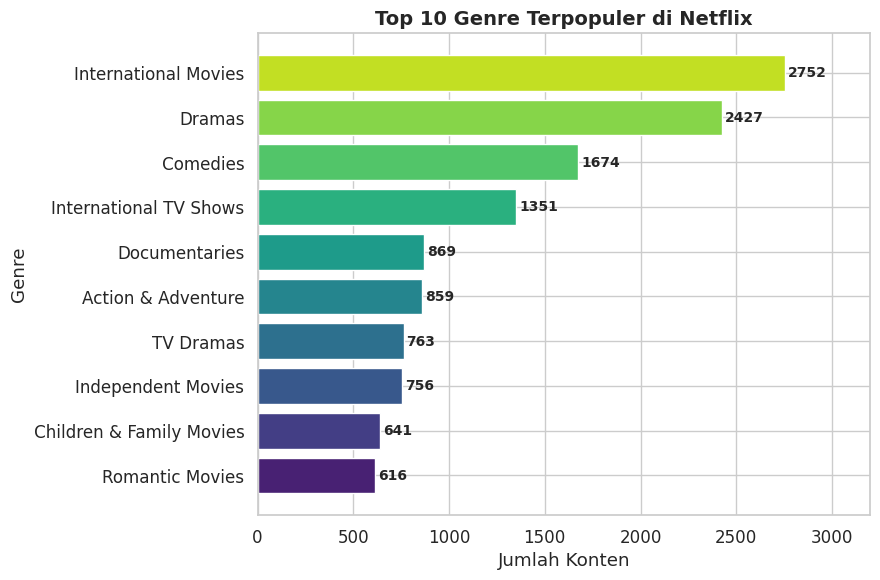

In [24]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(9, 6))
bars = plt.barh(genre_counts.index[::-1], genre_counts.values[::-1],
                color=sns.color_palette('viridis', 10), edgecolor='white')
plt.title('Top 10 Genre Terpopuler di Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Konten')
plt.ylabel('Genre')
for i, v in enumerate(genre_counts.values[::-1]):
    plt.text(v + 15, i, str(v), va='center', fontsize=10, fontweight='bold')
plt.xlim(0, 3200)
plt.tight_layout()
plt.show()

**Insight**
- **International Movies** menjadi genre terbanyak dengan **2.752 konten**, menunjukkan Netflix aktif menghadirkan konten dari luar Amerika.
- **Dramas (2.427)** dan **Comedies (1.674)** konsisten menjadi genre favorit lintas budaya.
- Genre **Action & Adventure** dan **Documentaries** juga cukup kuat dengan masing-masing ~859 dan ~869 konten.

**Rekomendasi Tindakan**
- **Produser konten Indonesia** berpeluang besar masuk Netflix karena permintaan International Movies sangat tinggi.
- Jika ingin membuat konten yang mudah diterima pasar global, fokus pada genre **Drama atau Comedy** karena paling universal.
- Netflix bisa mempertimbangkan untuk **memperkuat genre niche** (Sport, Sci-Fi) agar membedakan diri dari kompetitor.


---
## **1.3 Composition — Proporsi Negara Produksi (Pie Chart)**

**Aktivitas:** Menampilkan proporsi kontribusi negara produksi terhadap total konten Netflix.

**Tujuan:** Melihat seberapa besar dominasi negara tertentu dalam katalog Netflix secara keseluruhan.

**Visualisasi:** Pie Chart


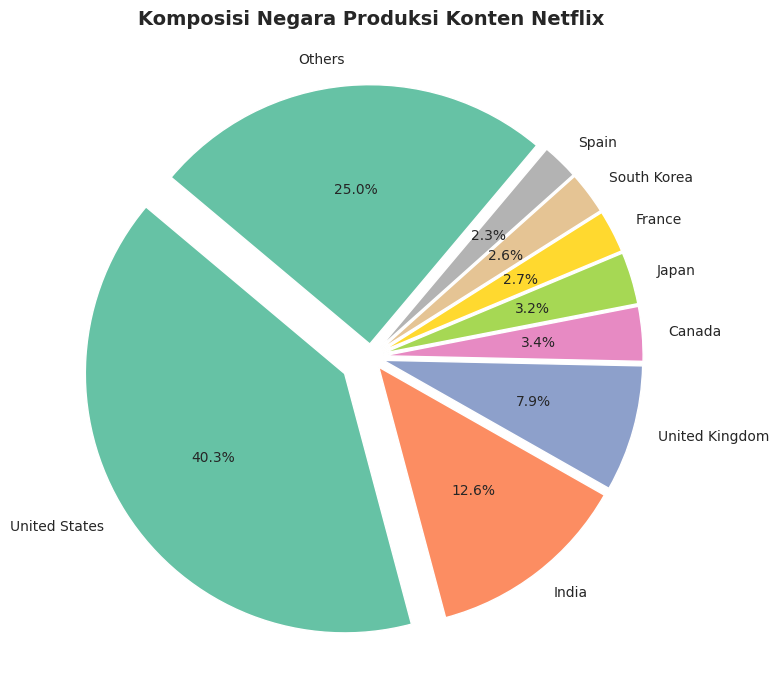

In [25]:
df_country = df[df['primary_country'] != 'Unknown']
top_c = df_country['primary_country'].value_counts()
top8  = top_c.head(8)
others_val = top_c.iloc[8:].sum()

pie_data   = list(top8.values) + [others_val]
pie_labels = list(top8.index)  + ['Others']
colors_pie = sns.color_palette('Set2', len(pie_data))
explode    = [0.05] * len(pie_data)
explode[0] = 0.12

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
        colors=colors_pie, explode=explode, startangle=140,
        textprops={'fontsize': 10})
plt.title('Komposisi Negara Produksi Konten Netflix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**
- **United States** mendominasi dengan proporsi terbesar (~40%), hampir setara dengan gabungan semua negara lainnya.
- **India** menyumbang porsi signifikan (~12%), mencerminkan besarnya industri film Bollywood.
- Negara-negara Asia (Japan, South Korea) dan Eropa (UK) juga memiliki representasi yang cukup.

**Rekomendasi Tindakan**
- Netflix perlu **menjaga keseimbangan** agar tidak terlalu US-sentris demi menjaga pengguna di negara berkembang.
- Kategori **'Others'** yang besar (~28%) menunjukkan potensi ekspansi konten dari negara-negara yang belum terwakili.
- Strategi **'local content'** seperti yang dilakukan Netflix Indonesia berpotensi meningkatkan engagement pengguna lokal.


---
## **1.4 Composition — Top 10 Negara Produksi (Bar Chart)**

**Aktivitas:** Membandingkan jumlah absolut konten dari 10 negara produksi teratas.

**Tujuan:** Melihat ranking negara berdasarkan jumlah konten yang diproduksi secara lebih detail.

**Visualisasi:** Bar Chart


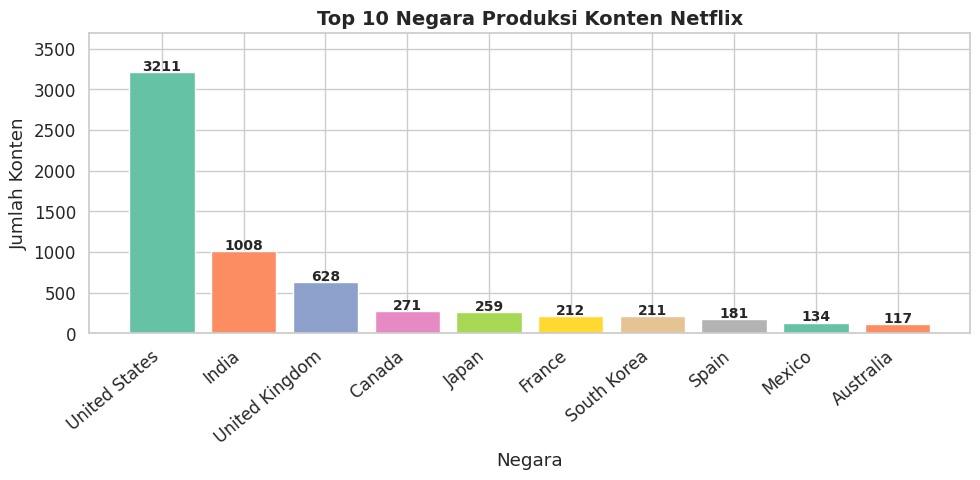

In [26]:
df_country = df[df['primary_country'] != 'Unknown']
top10_c = df_country['primary_country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(top10_c.index, top10_c.values,
               color=sns.color_palette('Set2', 10), edgecolor='white')
plt.title('Top 10 Negara Produksi Konten Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Negara')
plt.ylabel('Jumlah Konten')
plt.xticks(rotation=40, ha='right')
for i, v in enumerate(top10_c.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, max(top10_c.values) * 1.15)
plt.tight_layout()
plt.show()

**Insight**
- **United States (2.818)** memimpin jauh dibanding negara lain — hampir 3x lipat India di posisi kedua.
- **South Korea (199)** masuk top 5 meskipun negara kecil, didorong popularitas K-Drama dan K-Movie global.
- Kesenjangan antara US (2.818) dan posisi ke-10 (Egypt ~106) sangat besar, menunjukkan dominasi yang ekstrem.

**Rekomendasi Tindakan**
- Negara dengan produksi rendah seperti **Indonesia, Brazil, Nigeria** memiliki ruang besar untuk tumbuh di Netflix.
- Keberhasilan **South Korea** bisa menjadi model — investasi di konten berkualitas tinggi bisa melampaui keterbatasan ukuran negara.
- Netflix bisa menerapkan **kuota konten lokal** per wilayah untuk mempercepat pertumbuhan di negara berkembang.


---
## **1.5 Distribution — Distribusi Tahun Rilis Konten**

**Aktivitas:** Menganalisis sebaran tahun rilis konten Netflix.

**Tujuan:** Mengetahui mayoritas konten berasal dari era mana.

**Visualisasi:** Histogram


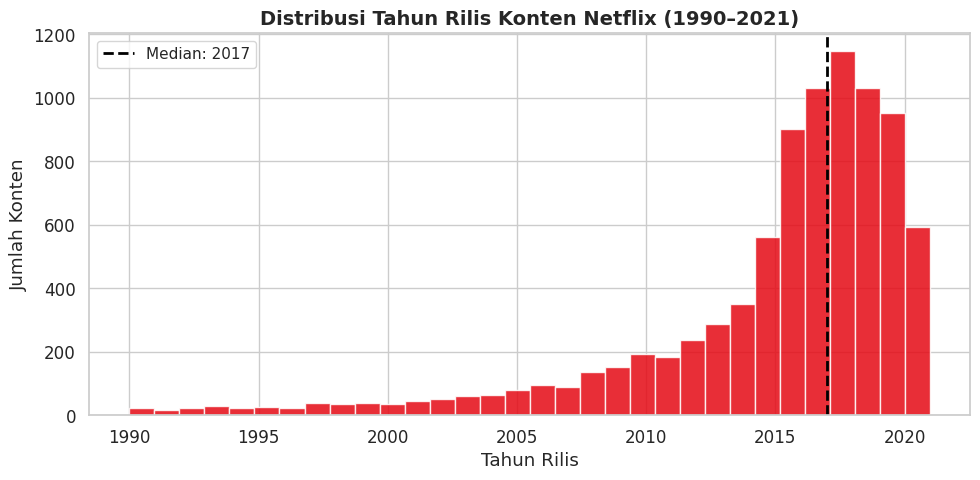

In [27]:
df_modern = df[df['release_year'] >= 1990]
median_year = int(df['release_year'].median())

plt.figure(figsize=(10, 5))
plt.hist(df_modern['release_year'], bins=32, color='#E50914', edgecolor='white', alpha=0.85)
plt.axvline(median_year, color='black', linestyle='--', linewidth=2,
            label=f'Median: {median_year}')
plt.title('Distribusi Tahun Rilis Konten Netflix (1990–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun Rilis')
plt.ylabel('Jumlah Konten')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Insight**
- Distribusi berbentuk **right-skewed** — konten Netflix didominasi oleh produksi terbaru, terutama **2015–2021**.
- Median tahun rilis adalah **2017**, artinya setengah dari seluruh konten dirilis di tahun 2017 ke atas.
- Konten lama (sebelum 2000) sangat sedikit, menandakan Netflix tidak terlalu fokus pada arsip klasik.

**Rekomendasi Tindakan**
- Pengguna yang suka **film klasik** mungkin perlu mencari platform lain seperti Criterion Channel atau Mubi.
- Netflix bisa **menambah koleksi film klasik** sebagai daya tarik segmen penonton yang lebih tua.
- Produsen konten sebaiknya **mengikuti tren konten baru** karena Netflix sangat mendominasi konten era modern.


---
## **1.6 Distribution — Tren Penambahan Konten per Tahun**

**Aktivitas:** Menganalisis tren jumlah konten yang ditambahkan ke Netflix per tahun.

**Tujuan:** Melihat pertumbuhan platform Netflix dari waktu ke waktu.

**Visualisasi:** Line Chart


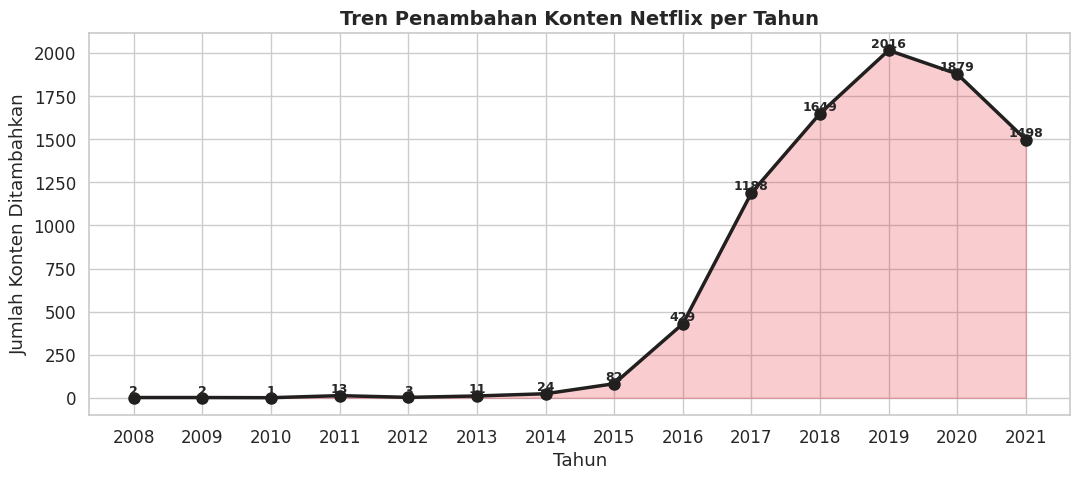

In [28]:
year_added = df.groupby('year_added').size().reset_index(name='count')
year_added = year_added[(year_added['year_added'] >= 2008) &
                         (year_added['year_added'] <= 2021)].copy()

plt.figure(figsize=(11, 5))
plt.plot(year_added['year_added'], year_added['count'],
         marker='o', color='#221F1F', linewidth=2.5, markersize=8)
plt.fill_between(year_added['year_added'], year_added['count'],
                 alpha=0.2, color='#E50914')
plt.title('Tren Penambahan Konten Netflix per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Konten Ditambahkan')
plt.xticks(year_added['year_added'].astype(int))
for _, row in year_added.iterrows():
    plt.text(row['year_added'], row['count'] + 18,
             str(int(row['count'])), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**
- Pertumbuhan konten sangat pesat dari **2015 (756 konten)** hingga puncaknya di **2019 (1.497 konten)** — naik hampir **2x lipat dalam 4 tahun**.
- Terjadi **penurunan tajam di 2020 dan 2021**, kemungkinan besar akibat pandemi COVID-19 yang menghambat produksi.
- Sebelum 2015, pertumbuhan sangat lambat — menandakan Netflix baru serius ekspansi konten di pertengahan 2010-an.

**Rekomendasi Tindakan**
- Netflix perlu **strategi recovery pasca pandemi** untuk mengembalikan laju penambahan konten ke angka puncak 2019.
- Investasi di **konten original (Netflix Original)** bisa menjadi solusi karena tidak bergantung pada studio eksternal.
- Data 2021 yang masih rendah bisa juga berarti dataset belum lengkap — perlu diverifikasi dengan sumber terkini.


---
## **1.7 Relationship — Rating Konten berdasarkan Tipe**

**Aktivitas:** Menganalisis hubungan antara rating konten dengan tipe (Movie vs TV Show).

**Tujuan:** Mengetahui apakah Movie dan TV Show memiliki pola rating yang berbeda.

**Visualisasi:** Grouped Bar Chart


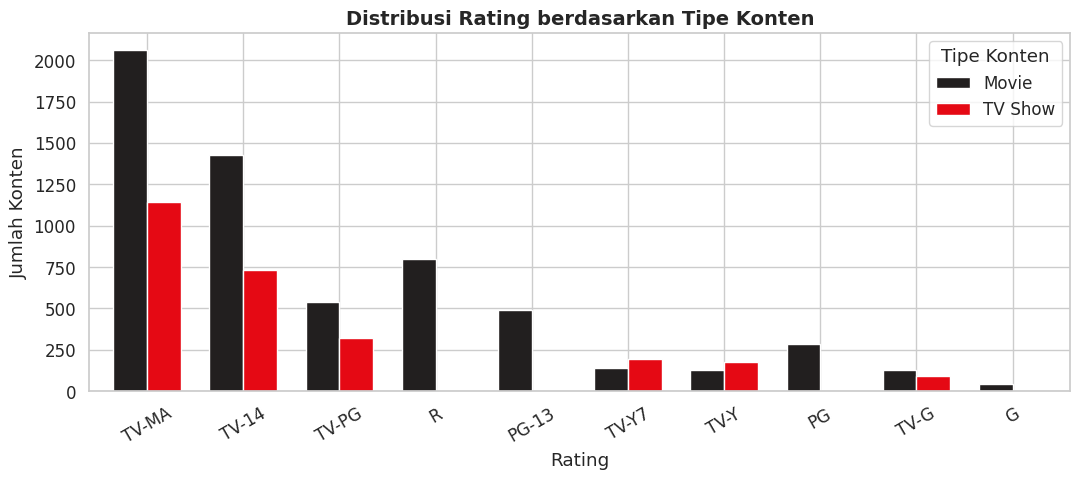

In [29]:
valid_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G', 'G']
df_rated = df[df['rating'].isin(valid_ratings)]
rating_type = df_rated.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_type = rating_type.loc[[r for r in valid_ratings if r in rating_type.index]]

plt.figure(figsize=(11, 5))
rating_type.plot(kind='bar', color=['#221F1F', '#E50914'],
                 edgecolor='white', width=0.7,
                 ax=plt.gca())
plt.title('Distribusi Rating berdasarkan Tipe Konten', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Jumlah Konten')
plt.xticks(rotation=30)
plt.legend(title='Tipe Konten')
plt.tight_layout()
plt.show()

**Insight**
- Rating **TV-MA** (dewasa) sangat mendominasi, terutama dari TV Show — ini adalah rating tertinggi di Netflix.
- **Movie** lebih banyak menggunakan rating film standar (**R, PG-13**), sedangkan **TV Show** mayoritas menggunakan rating TV (**TV-MA, TV-14**).
- Rating ramah anak seperti **TV-Y, TV-G, G** sangat sedikit — Netflix bukan platform utama untuk konten anak-anak.

**Rekomendasi Tindakan**
- Orang tua yang ingin menggunakan Netflix untuk anak perlu **aktif menggunakan fitur parental control**.
- Netflix bisa **memperbanyak konten kids (TV-Y, G)** untuk bersaing dengan Disney+ yang lebih kuat di segmen ini.
- Pengiklan yang menyasar **remaja dan dewasa muda** sebaiknya fokus beriklan di konten TV-MA dan TV-14.


---
## **1.8 Relationship — Heatmap Genre vs Rating**

**Aktivitas:** Menganalisis hubungan antara genre dengan rating menggunakan heatmap.

**Tujuan:** Menemukan pola kombinasi genre-rating yang paling umum di Netflix.

**Visualisasi:** Heatmap


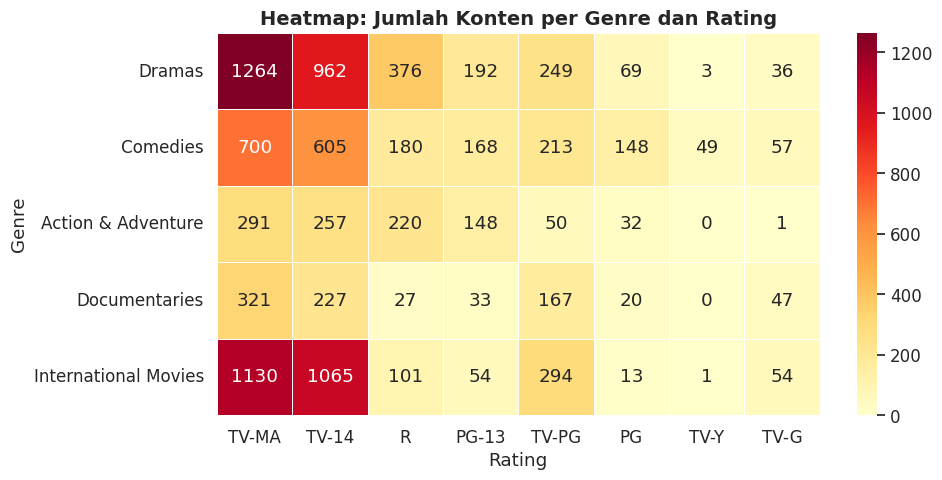

In [30]:
top_genres_list  = ['Dramas', 'Comedies', 'Action & Adventure',
                     'Documentaries', 'International Movies']
top_ratings_list = ['TV-MA', 'TV-14', 'R', 'PG-13', 'TV-PG', 'PG', 'TV-Y', 'TV-G']

heatmap_data = {}
for genre in top_genres_list:
    row = {}
    for rating in top_ratings_list:
        count = len(df[(df['listed_in'].str.contains(genre, na=False)) &
                        (df['rating'] == rating)])
        row[rating] = count
    heatmap_data[genre] = row

hm_df = pd.DataFrame(heatmap_data).T

plt.figure(figsize=(10, 5))
sns.heatmap(hm_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Heatmap: Jumlah Konten per Genre dan Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Insight**
- **Dramas + TV-MA** adalah kombinasi paling dominan — drama dewasa menjadi konten andalan Netflix.
- **Comedies** tersebar cukup merata di berbagai rating, menandakan genre ini lebih inklusif untuk semua usia.
- **Documentaries** cenderung memiliki rating **TV-MA dan TV-14** — menunjukkan topik yang dibahas serius dan dewasa.
- **International Movies** dengan rating **TV-MA dan TV-14** sangat banyak, menunjukkan konten internasional umumnya ditujukan untuk dewasa.

**Rekomendasi Tindakan**
- Kreator yang ingin kontennya masuk Netflix sebaiknya membuat **Drama dengan rating TV-MA** karena ini kombinasi paling diminati platform.
- **Comedy yang family-friendly (PG/TV-PG)** masih memiliki celah yang bisa diisi karena jumlahnya relatif kecil.
- Platform dapat menggunakan pola ini untuk **sistem rekomendasi** — pengguna yang suka Drama TV-MA cenderung juga suka Thriller atau Action dewasa.


---
# **Kesimpulan**

Berdasarkan Exploratory Data Analysis pada dataset Netflix Titles (8.807 baris, 12 kolom):

**1. Comparison**
Movie mendominasi katalog Netflix (69.6%). Genre International Movies, Dramas, dan Comedies adalah yang terbanyak — menunjukkan Netflix aktif menghadirkan konten global lintas genre.

**2. Composition**
United States menjadi produsen konten terbesar (~36%), diikuti India (~12%). Meski beragam, katalog Netflix masih sangat US-sentris.

**3. Distribution**
Mayoritas konten dirilis di era modern (2015–2021) dengan median 2017. Puncak penambahan konten terjadi di 2019 (1.497 judul), lalu menurun akibat pandemi COVID-19.

**4. Relationship**
Netflix secara jelas menyasar penonton dewasa — TV-MA adalah rating paling dominan. Dramas dan Action & Adventure didominasi konten berrating tinggi, sementara Comedies lebih inklusif untuk semua usia.
